# 1. Importing Libraries and Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

Loading the Dataset

In [9]:
dataset = pd.read_csv('https://raw.githubusercontent.com/NANIJ-code/customer-churn-analysis/5143d735dc1ac3e4c8226fd82b627b203e77616b/data/Telco-Customer-Churn.csv')

dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Understanding the Dataset

In [10]:
print(dataset.isnull().sum())
print(dataset.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Handling Missing and Incorrect Values

In [16]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())

print(f"Dataset ready: {dataset.shape[0]} customers and {dataset.shape[1]} variables.")

Dataset ready: 7043 customers and 21 variables.


# 2. Analyzing the Overall Churn Distribution

We check the percentage of churners and non-churners to understand the balance of the dataset.

Churn
No     5174
Yes    1869
Name: count, dtype: int64


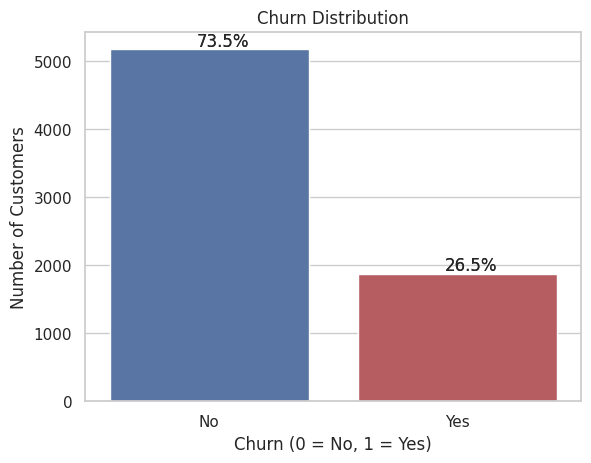

In [19]:
print(dataset['Churn'].value_counts())
sns.countplot(x='Churn', data=dataset, palette='coolwarm', hue='Churn', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

# Create a countplot using Seaborn
ax = sns.countplot(data=dataset, x='Churn', palette=['#4C72B0', '#C44E52'], hue='Churn', legend=False)
total = len(dataset)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 50
    ax.annotate(percentage, (x, y), size=12)

plt.show()

The overall churn rate is 26.5%. The goal of the following analyses is to understand the customer segments that make up this quarter of lost customers.

# 3. Evaluating the Impact of Contract Type on Churn

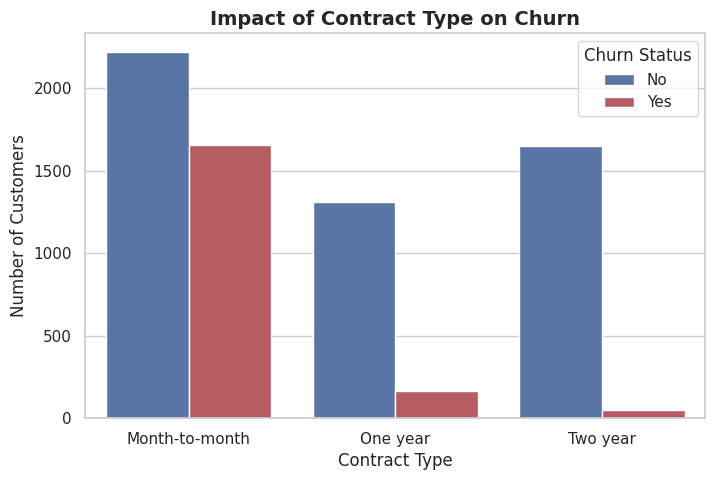

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'])

plt.title("Impact of Contract Type on Churn", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title='Churn Status')

plt.show()

The chart clearly shows that the risk of flight is heavily concentrated on "Month-to-month" contracts (no long-term commitment). Customers with 1 or 2-year contracts are extremely loyal.

# 4. Investigating Customer Tenure and Attrition Risk

We use a histogram here to identify exactly which months pose the highest risk.

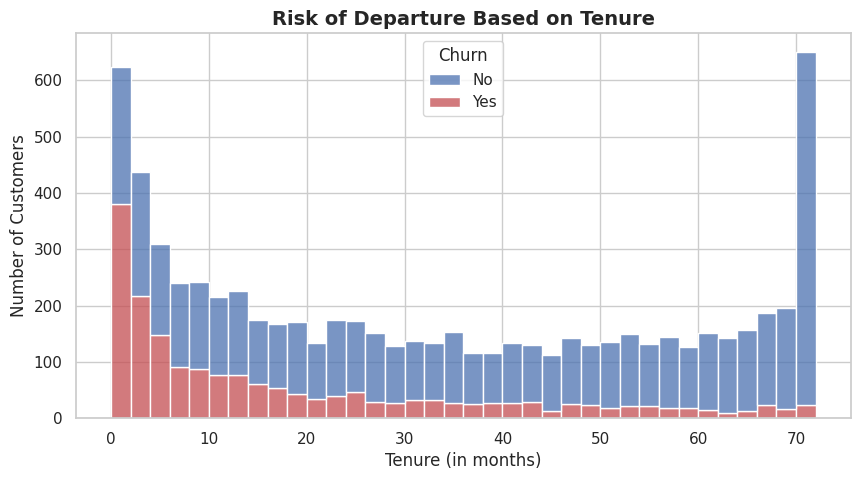

In [21]:
plt.figure(figsize=(10, 5))
# KDE = False because we want to see the actual volumes
sns.histplot(data=dataset, x='tenure', hue='Churn', multiple='stack', bins=36, palette=['#4C72B0', '#C44E52'])

plt.title("Risk of Departure Based on Tenure", fontsize=14, fontweight='bold')
plt.xlabel("Tenure (in months)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

The absolute danger zone is within the first 6 months. If a customer survives their first year, the probability of churn drops drastically. Recommendation: Implement an aggressive loyalty program during the first semester.

# 5. Comparing Monthly Charges Between Customer Groups

We use a Boxplot to compare the median monthly billing of those who stay versus those who leave.

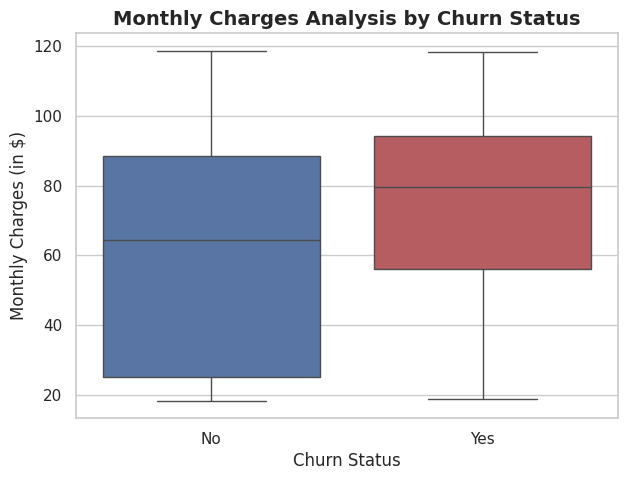

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=dataset, x='Churn', y='MonthlyCharges', hue='Churn', palette=['#4C72B0', '#C44E52'])

plt.title("Monthly Charges Analysis by Churn Status", fontsize=14, fontweight='bold')
plt.xlabel("Churn Status", fontsize=12)
plt.ylabel("Monthly Charges (in $)", fontsize=12)

plt.show()

 The median monthly bill for churning customers is significantly higher than that of loyal customers (approximately 80 compared to 65). Pricing is a major driver of departure.